[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/probability_statistics/08_law_of_large_numbers_and_clt/first_principles.ipynb)

# Module 08 — Law of Large Numbers and the Central Limit Theorem

## 1. Why This Module Exists

Every empirical claim about a random system is ultimately an average: the fraction of coin flips that landed heads, the mean energy of molecules in a gas, the training loss over a minibatch, the estimated integral in a Monte Carlo simulation. The entire practice rests on one belief — that averaging many independent replications of a noisy quantity produces something stable. This module turns that belief into two theorems, and then goes further, describing exactly how large the leftover error is and what shape it has.

The **law of large numbers** (LLN) is the first-order statement: the sample mean $\bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i$ of i.i.d. observations converges to the population mean $\mu$. Randomness averages out, and empirical frequencies become probabilities. The **central limit theorem** (CLT) is the sharper second-order statement: the residual fluctuation $\bar{X}_n - \mu$, magnified by $\sqrt{n}$, converges in distribution to a Gaussian with variance $\sigma^2$ — *whatever the shape of the underlying law*. The first theorem licenses estimation; the second quantifies its error, and is why a Gaussian appears in places that have nothing to do with each other.

Without these two results almost nothing downstream is legitimate. A confidence interval is a CLT statement. A Monte Carlo error bar is a CLT statement. The claim that a minibatch gradient points, on average, in the direction of the full gradient is an LLN statement; the claim that its noise scales as $B^{-1/2}$ is a CLT statement. The reason thermal noise, diffusion and measurement error are all modelled as Gaussian is the CLT applied to a sum of many small independent contributions.

The module also draws the boundary. The theorems have hypotheses — integrability for the LLN, finite variance for the CLT — and each hypothesis fails somewhere real. Cauchy summands defeat averaging outright; heavy-tailed summands with infinite variance converge to $\alpha$-stable laws instead of Gaussians; non-identically-distributed summands need a Lindeberg condition. Knowing where the theorems stop is as practical as knowing that they hold, because a $\sigma/\sqrt{n}$ error bar computed outside their range is not conservative, it is wrong.

## 2. Intuition

Start with the arithmetic that drives everything. If $X_1, \ldots, X_n$ are independent with common mean $\mu$ and variance $\sigma^2$, then linearity of expectation and additivity of variance under independence give

$$
E[\bar{X}_n] = \mu, \qquad \bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i ,
$$

and

$$
\boxed{\operatorname{Var}(\bar{X}_n) = \frac{\sigma^2}{n}}
$$

**Interpretation.** The centre of the sampling distribution does not move with $n$, while its spread shrinks like $1/n$ in variance, i.e. like $1/\sqrt{n}$ in standard deviation. The consequence is that both theorems of this module are already visible in one line: the shrinking spread *is* the law of large numbers, and the exact rate $\sigma/\sqrt{n}$ is the scale at which the central limit theorem lives. Nothing else in the module changes this scale; the theorems only say what happens *at* it.

### 2.1 Why fluctuations shrink: cancellation, not compensation

Independence means deviations are unrelated across draws, so in the centred sum $S_n^{c} = \sum_i (X_i - \mu)$ the cross terms have zero expectation:

$$
E\left[S_n^{c\,2}\right] = \sum_{i} E\left[(X_i-\mu)^2\right] + \sum_{i \ne j} \underbrace{E\left[(X_i-\mu)(X_j-\mu)\right]}_{=\,0} = n\sigma^2 .
$$

So the *absolute* surplus $S_n^{c}$ grows like $\sqrt{n}$ — it does not shrink, and it does not get corrected. What shrinks is the surplus *per observation*, $S_n^{c}/n \sim n^{-1/2}$. A run of tails is never repaid; it is diluted. This single distinction dissolves the gambler's fallacy: the law of large numbers is a statement about ratios, never about debts.

### 2.2 Why the limit shape is Gaussian

Universality is the surprising half. Consider adding two independent copies of any centred law: the density of the sum is the convolution of the two densities, and convolution smooths. Iterating the operation "convolve, then rescale by $\sqrt{2}$" repeatedly is a map on the space of standardized distributions, and the Gaussian is its fixed point — the only fixed point with finite variance.

The mechanism becomes exact in Fourier language. The characteristic function turns convolution into multiplication, so the standardized sum has characteristic function $[\varphi(t/\sqrt{n})]^n$. Expanding $\varphi$ to second order at the origin keeps exactly two pieces of information about the summand — its mean and its variance — and destroys every other feature in the limit. Skewness, kurtosis and the shape of the tail all enter at order $n^{-1/2}$ or smaller. That is why the Gaussian is universal, and also why the approach is *slow*: the discarded information leaks back in through the $n^{-1/2}$ Berry–Esseen term.

### 2.3 Three modes of convergence, and why they must be kept apart

The two theorems live on different notions of convergence.

- **In probability** (weak LLN): for each fixed tolerance, the chance of a bad average vanishes as $n$ grows. Individual bad excursions may still occur infinitely often.
- **Almost surely** (strong LLN): with probability one, the entire trajectory $n \mapsto \bar{X}_n$ eventually stays inside any tolerance forever. Bad excursions stop.
- **In distribution** (CLT): only the *shape* of the rescaled law converges. The random variables themselves need not converge to anything, and need not even live on the same probability space.

The hierarchy is almost sure $\Rightarrow$ in probability $\Rightarrow$ in distribution, with no implication running backwards in general. A useful picture: weak convergence says each snapshot is good; strong convergence says the whole movie settles; convergence in distribution says only the histogram settles.

The shared computational environment for the whole notebook. Every random draw in this module comes from the single generator `rng`, so every number below is reproducible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

from scipy.stats import binom, cauchy, gamma, norm, poisson

print("environment ready")

environment ready


The figure below is the diagnostic of Section 7.2, run on four summands chosen to sit on
different sides of the theorems' hypotheses: Bernoulli$(1/2)$ and Exponential$(1)$ satisfy
both LLN and CLT; Pareto$(\alpha = 1.5)$ has a finite mean but infinite variance, so the LLN
holds and the $\pm 2\sigma/\sqrt{n}$ envelope does not exist; standard Cauchy has no mean at
all, so no LLN holds.

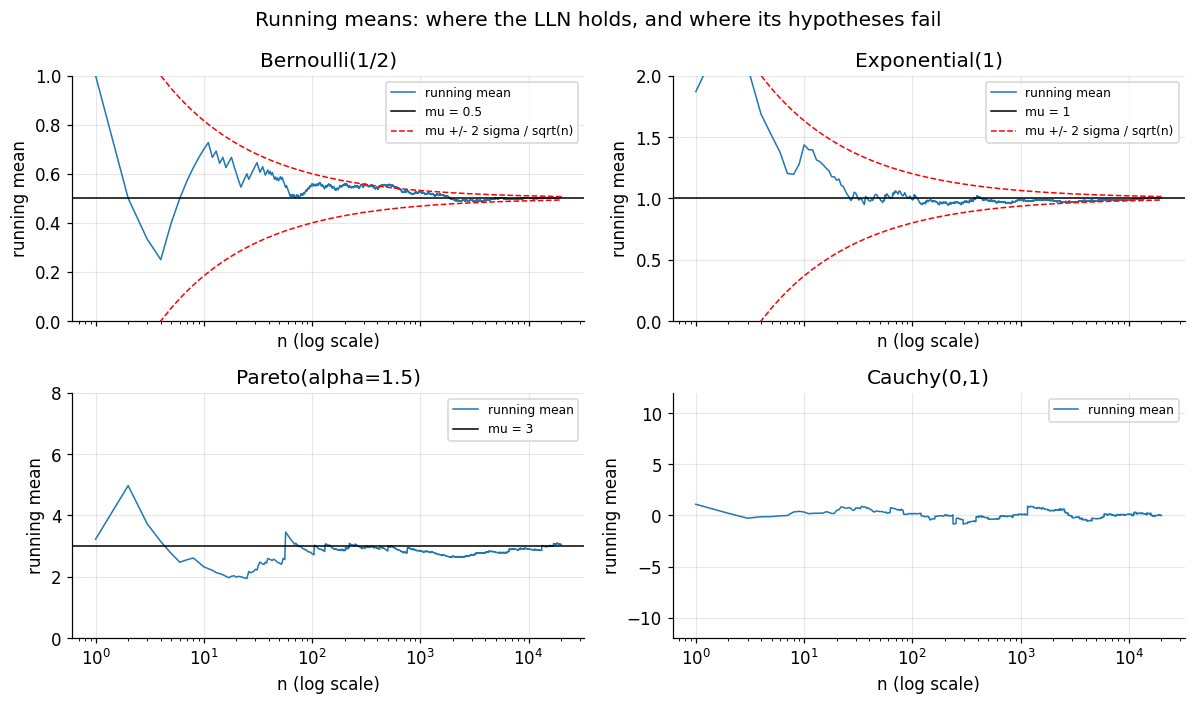

fraction of n with running mean outside the 2-sigma envelope: {'Bernoulli(1/2)': 0.0106, 'Exponential(1)': 5e-05}


In [2]:
n_max = 20_000
ns = np.arange(1, n_max + 1)

samples = {
    "Bernoulli(1/2)": (rng.binomial(1, 0.5, n_max), 0.5, 0.5),
    "Exponential(1)": (rng.exponential(1.0, n_max), 1.0, 1.0),
    "Pareto(alpha=1.5)": (rng.uniform(size=n_max) ** (-1 / 1.5), 3.0, np.inf),
    "Cauchy(0,1)": (rng.standard_cauchy(n_max), np.nan, np.inf),
}

fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True)
for ax, (name, (x, mu, sd)) in zip(axes.ravel(), samples.items()):
    run = np.cumsum(x) / ns
    ax.plot(ns, run, lw=1.0, color="C0", label="running mean")
    if np.isfinite(mu):
        ax.axhline(mu, color="k", lw=1.0, ls="-", label=f"mu = {mu:g}")
    if np.isfinite(sd):
        ax.plot(ns, mu + 2 * sd / np.sqrt(ns), "r--", lw=1.0,
                label="mu +/- 2 sigma / sqrt(n)")
        ax.plot(ns, mu - 2 * sd / np.sqrt(ns), "r--", lw=1.0)
    ax.set_xscale("log")
    ax.set_title(name)
    ax.set_xlabel("n (log scale)")
    ax.set_ylabel("running mean")
    ax.legend(fontsize=8, loc="upper right")
axes[0, 0].set_ylim(0.0, 1.0)
axes[0, 1].set_ylim(0.0, 2.0)
axes[1, 0].set_ylim(0.0, 8.0)
axes[1, 1].set_ylim(-12.0, 12.0)
fig.suptitle("Running means: where the LLN holds, and where its hypotheses fail")
fig.tight_layout()
plt.show()

frac_outside = {}
for name, (x, mu, sd) in samples.items():
    if np.isfinite(sd):
        run = np.cumsum(x) / ns
        frac_outside[name] = float(np.mean(np.abs(run - mu) > 2 * sd / np.sqrt(ns)))
print("fraction of n with running mean outside the 2-sigma envelope:", frac_outside)

The two finite-variance running means stay inside the shrinking envelope for over $98\%$ of
all $n$ — a running mean is a strongly autocorrelated path, so it leaves the band in long rare
excursions rather than at $5\%$ of the indices independently. Pareto$(1.5)$
still converges to its mean $3$ — the LLN needs only integrability — but it does so through
visible jumps caused by single large draws, and no envelope of width $c/\sqrt{n}$ contains it,
because $\sigma = \infty$. The Cauchy running mean never settles at any level: it is exactly
standard Cauchy for every $n$, a fact proved in Proof 5.6.

## 3. Definitions

### Definition 3.1 (Convergence in probability)

$X_n \xrightarrow{P} X$ iff for every $\varepsilon \gt 0$,

$$
\lim_{n \to \infty} P\left(\vert X_n - X \vert \gt \varepsilon\right) = 0 .
$$

### Definition 3.2 (Almost sure convergence)

$X_n \xrightarrow{a.s.} X$ iff

$$
P\left(\left\{\omega : \lim_{n \to \infty} X_n(\omega) = X(\omega)\right\}\right) = 1 .
$$

### Definition 3.3 (Convergence in distribution)

$X_n \xrightarrow{d} X$ iff $F_{X_n}(x) \to F_X(x)$ at every continuity point $x$ of $F_X$; equivalently $E[h(X_n)] \to E[h(X)]$ for every bounded continuous $h$.

### Definition 3.4 (Characteristic function)

For a random variable $X$,

$$
\varphi_X(t) = E\left[e^{itX}\right], \qquad t \in \mathbb{R} .
$$

It always exists, because the integrand has modulus $1$; it determines the law uniquely; it factorizes over independent sums, $\varphi_{X+Y} = \varphi_X\varphi_Y$; and it obeys the affine rule $\varphi_{aX+b}(t) = e^{itb}\varphi_X(at)$. If $E\vert X \vert^k \lt \infty$ then $\varphi_X$ is $k$ times differentiable with $\varphi_X^{(k)}(0) = i^k E[X^k]$.

### Definition 3.5 (Stochastic order symbols)

A sequence $R_n$ is $o_P(1)$ if $R_n \xrightarrow{P} 0$, and $O_P(1)$ if it is bounded in probability: for every $\delta \gt 0$ there is $M$ with $\sup_n P(\vert R_n\vert \gt M) \lt \delta$. Any sequence converging in distribution is $O_P(1)$, and a product of an $O_P(1)$ and an $o_P(1)$ sequence is $o_P(1)$.

### Definition 3.6 (Triangular array and the Lindeberg condition)

A *triangular array* is a doubly indexed family $\{X_{n,k} : 1 \le k \le k_n\}$, independent within each row $n$, with $E[X_{n,k}] = 0$ and $s_n^2 = \sum_{k=1}^{k_n} \operatorname{Var}(X_{n,k}) \in (0,\infty)$. The array satisfies the **Lindeberg condition** if for every $\varepsilon \gt 0$

$$
L_n(\varepsilon) = \frac{1}{s_n^2}\sum_{k=1}^{k_n} E\left[X_{n,k}^2\,\mathbf{1}\{\vert X_{n,k}\vert \gt \varepsilon s_n\}\right] \xrightarrow[n \to \infty]{} 0 .
$$

In words: no single summand contributes a non-vanishing share of the total variance.

## 4. Main Results

### Theorem 4.1 (Markov's inequality)

If $Y \ge 0$ and $a \gt 0$, then

$$
P(Y \ge a) \le \frac{E[Y]}{a} .
$$

*Hypotheses.* Nonnegativity of $Y$ is what makes the pointwise bound $a\mathbf{1}\{Y \ge a\} \le Y$ true off the event, and $a \gt 0$ is needed to divide.

### Theorem 4.2 (Chebyshev's inequality)

If $E[X] = \mu$ and $\operatorname{Var}(X) = \sigma^2 \lt \infty$, then for every $\varepsilon \gt 0$,

$$
P\left(\vert X - \mu \vert \ge \varepsilon\right) \le \frac{\sigma^2}{\varepsilon^2} .
$$

*Hypotheses.* Finiteness of $\sigma^2$ is what makes the right side informative; with $\sigma^2 = \infty$ the bound is vacuously true and useless.

### Theorem 4.3 (Weak law of large numbers)

Let $X_1, X_2, \ldots$ be i.i.d. with $E\vert X_1 \vert \lt \infty$ and $E[X_1] = \mu$. Then

$$
\bar{X}_n \xrightarrow{P} \mu .
$$

*Hypotheses.* Independence is what makes $\operatorname{Var}(\bar{X}_n) = \sigma^2/n$ (or, without a variance, what makes truncation errors summable); identical distribution fixes a single target $\mu$; integrability is what makes $\mu$ exist at all. Proof 5.2 assumes in addition $\sigma^2 \lt \infty$ and removes that assumption by truncation.

### Theorem 4.4 (Strong law of large numbers, Kolmogorov)

If $X_1, X_2, \ldots$ are i.i.d. with $E\vert X_1 \vert \lt \infty$ and mean $\mu$, then

$$
P\left(\lim_{n \to \infty} \bar{X}_n = \mu\right) = 1 .
$$

Conversely, if $E\vert X_1 \vert = \infty$ then $\limsup_n \vert \bar{X}_n \vert = \infty$ almost surely: integrability is not a technical convenience but a sharp threshold. Proof 5.3 proves the theorem under the additional hypothesis $E[(X_1-\mu)^4] \lt \infty$; the general case is Durrett, *Probability: Theory and Examples*, 5th ed., §2.4 (Thm 2.4.1).

### Lemma 4.5 (Borel–Cantelli)

For events $A_1, A_2, \ldots$:

1. If $\sum_n P(A_n) \lt \infty$, then $P(A_n \text{ infinitely often}) = 0$.
2. If the $A_n$ are independent and $\sum_n P(A_n) = \infty$, then $P(A_n \text{ i.o.}) = 1$.

*Hypotheses.* Part 1 needs nothing but countable subadditivity. Part 2 genuinely needs independence, and is not used in this module.

### Theorem 4.6 (Lévy continuity theorem — cited, not proved here)

If $\varphi_{X_n}(t) \to \varphi(t)$ pointwise for every $t \in \mathbb{R}$ and $\varphi$ is continuous at $0$, then $\varphi$ is the characteristic function of some random variable $X$ and $X_n \xrightarrow{d} X$.

*Hypotheses.* Pointwise convergence alone is not enough: continuity of the limit at $0$ is what rules out escape of mass to infinity. Reference: Billingsley, *Probability and Measure*, 3rd ed., §26 (Thm 26.3). This is the one external ingredient of Proof 5.4; it is a statement about weak convergence of measures, proved by a tightness argument, and it does not presuppose the central limit theorem.

### Theorem 4.7 (Central limit theorem, Lindeberg–Lévy)

Let $X_1, X_2, \ldots$ be i.i.d. with mean $\mu$ and variance $\sigma^2 \in (0, \infty)$. Then

$$
\boxed{Z_n = \frac{\sqrt{n}\left(\bar{X}_n - \mu\right)}{\sigma} = \frac{S_n - n\mu}{\sigma\sqrt{n}} \;\xrightarrow{d}\; \mathcal{N}(0, 1)}
$$

*Hypotheses.* Independence gives the product formula in Step 2 of Proof 5.4; identical distribution gives a single characteristic function to raise to the $n$-th power; $\sigma^2 \lt \infty$ gives the second-order Taylor expansion; $\sigma^2 \gt 0$ excludes the degenerate case in which $Z_n$ is undefined.

**Interpretation.** The statement is about the *magnified* deviation, not about $\bar{X}_n$: the sample mean collapses to a point mass at $\mu$, and only after multiplying its error by $\sqrt{n}$ does a nondegenerate limit appear. The working consequence is the approximation $\bar{X}_n \approx \mathcal{N}(\mu, \sigma^2/n)$, which turns any sample mean into a confidence interval without knowing the law of $X_1$.

### Theorem 4.8 (Lindeberg–Feller CLT — cited, not proved here)

Let $\{X_{n,k}\}$ be a triangular array as in Definition 3.6 satisfying the Lindeberg condition. Then

$$
\frac{1}{s_n}\sum_{k=1}^{k_n} X_{n,k} \;\xrightarrow{d}\; \mathcal{N}(0,1) .
$$

*Hypotheses.* Row-wise independence replaces full independence; the Lindeberg condition replaces identical distribution, and is exactly the statement that no single term dominates the variance budget. Reference: Billingsley, *Probability and Measure*, 3rd ed., §27 (Thm 27.2). Theorem 4.7 is the special case $k_n = n$, $X_{n,k} = X_k - \mu$, $s_n^2 = n\sigma^2$, where the Lindeberg ratio reduces to $\sigma^{-2}E[(X_1-\mu)^2\mathbf{1}\{\vert X_1-\mu\vert \gt \varepsilon\sigma\sqrt{n}\}] \to 0$ by dominated convergence.

### Corollary 4.9 (Lyapunov's condition)

If for some $\delta \gt 0$

$$
\frac{1}{s_n^{2+\delta}}\sum_{k=1}^{k_n} E\left[\vert X_{n,k}\vert^{2+\delta}\right] \to 0 ,
$$

then the Lindeberg condition holds, and hence so does the conclusion of Theorem 4.8. Lyapunov's condition is checkable from moments alone, which is why it is the version used in practice.

### Theorem 4.10 (Berry–Esseen — cited, not proved here)

Under the hypotheses of Theorem 4.7, if in addition $\rho = E\vert X_1 - \mu\vert^3 \lt \infty$, then

$$
\boxed{\sup_{x \in \mathbb{R}} \left\vert P(Z_n \le x) - \Phi(x) \right\vert \le \frac{C\rho}{\sigma^3 \sqrt{n}}, \qquad C \lt 0.4748}
$$

*Hypotheses.* A third absolute moment is needed because the error is governed by the first term the second-order Taylor expansion discards. Reference: Feller, *An Introduction to Probability Theory and Its Applications*, Vol. 2, 2nd ed., §XVI.5; the constant $C \lt 0.4748$ is due to Shevtsova (2011).

**Interpretation.** The bound converts the CLT from an asymptotic statement into a usable finite-sample guarantee, and it identifies the only thing that governs speed: the dimensionless ratio $\rho/\sigma^3$, a scale-free measure of asymmetry and tail weight. The consequence is that "how large must $n$ be" has a formula, $n \gtrsim (C\rho/(\sigma^3\epsilon))^2$, and no universal constant such as $n \ge 30$ can appear in it.

### Theorem 4.11 (Slutsky)

If $X_n \xrightarrow{d} X$ and $Y_n \xrightarrow{P} c$ for a constant $c$, then $X_n + Y_n \xrightarrow{d} X + c$ and $X_n Y_n \xrightarrow{d} cX$.

*Hypotheses.* The limit of $Y_n$ must be a **constant**; for a genuinely random limit the joint law matters and the conclusion is false in general.

### Theorem 4.12 (Continuous mapping theorem)

If $X_n \xrightarrow{P} X$ and $h$ is continuous at every point of a set $C$ with $P(X \in C) = 1$, then $h(X_n) \xrightarrow{P} h(X)$. The same implication holds with $\xrightarrow{P}$ replaced by $\xrightarrow{d}$ throughout.

*Hypotheses.* Continuity is needed only on a set carrying the limit's whole mass, which is why $h(x) = 1/x$ may still be used when the limit is a nonzero constant.

### Theorem 4.13 (Delta method)

Suppose $\sqrt{n}(T_n - \theta) \xrightarrow{d} \mathcal{N}(0, \sigma^2)$ and $g$ is differentiable at $\theta$ with $g'(\theta) \ne 0$. Then

$$
\sqrt{n}\left(g(T_n) - g(\theta)\right) \xrightarrow{d} \mathcal{N}\left(0, \sigma^2 \left[g'(\theta)\right]^2\right) .
$$

*Hypotheses.* Differentiability **at the single point** $\theta$ suffices — Proof 5.5 uses only the definition of the derivative, never a mean-value remainder, so neither differentiability in a neighbourhood nor continuity of $g'$ is assumed. The condition $g'(\theta) \ne 0$ is what keeps the limit nondegenerate; when $g'(\theta) = 0$ the correct scaling is $n$ rather than $\sqrt{n}$ and the limit is a multiple of $\chi^2_1$.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorems 4.1 and 4.2)

**Markov.** Pointwise, the indicator bound

$$
a \cdot \mathbf{1}\{Y \ge a\} \le Y
$$

holds: where $Y \ge a$ the left side equals $a \le Y$; elsewhere the left side is $0 \le Y$ by nonnegativity. Taking expectations and using monotonicity and linearity,

$$
a\,P(Y \ge a) = E\left[a \mathbf{1}\{Y \ge a\}\right] \le E[Y] .
$$

Divide by $a \gt 0$. $\blacksquare$

**Chebyshev.** Apply Theorem 4.1 to $Y = (X - \mu)^2 \ge 0$ with threshold $a = \varepsilon^2$:

$$
P\left(\vert X - \mu \vert \ge \varepsilon\right) = P\left((X-\mu)^2 \ge \varepsilon^2\right) \le \frac{E[(X-\mu)^2]}{\varepsilon^2} = \frac{\sigma^2}{\varepsilon^2} . \qquad \blacksquare
$$

**Remark.** Both bounds are attained by two- or three-point laws, so neither can be improved without extra assumptions — which is precisely why they are weak for well-behaved laws. Sharper tools (Hoeffding, Bernstein, Chernoff) replace the second moment by the moment generating function and buy exponential rather than polynomial decay; Section 7.3 states the one this module uses.

### Proof 5.2 (of Theorem 4.3, finite-variance case)

Assume first $\sigma^2 = \operatorname{Var}(X_1) \lt \infty$. Linearity gives

$$
E[\bar{X}_n] = \frac{1}{n}\sum_{i=1}^n E[X_i] = \mu .
$$

Independence makes all covariances vanish, so variance is additive and picks up the factor $1/n^2$:

$$
\operatorname{Var}(\bar{X}_n) = \frac{1}{n^2}\sum_{i=1}^n \operatorname{Var}(X_i) = \frac{n\sigma^2}{n^2} = \frac{\sigma^2}{n} .
$$

Now apply Theorem 4.2 to $\bar{X}_n$ with any fixed $\varepsilon \gt 0$:

$$
P\left(\left\vert \bar{X}_n - \mu \right\vert \ge \varepsilon\right) \le \frac{\operatorname{Var}(\bar{X}_n)}{\varepsilon^2} = \frac{\sigma^2}{n\varepsilon^2} \xrightarrow[n \to \infty]{} 0 . \qquad \blacksquare
$$

**Rate.** The bound is non-asymptotic: to guarantee $P(\vert \bar{X}_n - \mu\vert \ge \varepsilon) \le \delta$ it suffices to take

$$
n \ge \frac{\sigma^2}{\varepsilon^2 \delta} ,
$$

so the sample complexity is linear in $1/\delta$. Exponential inequalities improve that to logarithmic.

**Removing the variance assumption.** For general $E\vert X_1\vert \lt \infty$, truncate at level $n$: set $Y_i = X_i \mathbf{1}\{\vert X_i \vert \le n\}$ and $\bar{Y}_n = n^{-1}\sum_i Y_i$. Dominated convergence gives $E[Y_1] \to \mu$, and $E[Y_1^2] \le n E\vert X_1\vert = o(n^2)/n \cdot n$, so $\operatorname{Var}(\bar{Y}_n) = o(1)$ and the argument above applies to $\bar{Y}_n$; meanwhile $P(\bar{X}_n \ne \bar{Y}_n) \le \sum_{i \le n} P(\vert X_i\vert \gt n) \le n P(\vert X_1 \vert \gt n) \to 0$ because $E\vert X_1\vert \lt \infty$. Combining the two pieces gives $\bar{X}_n \xrightarrow{P} \mu$ with no variance assumption.

### Proof 5.3 (of Theorem 4.4 under a fourth moment)

**Claim.** If $X_1, X_2, \ldots$ are i.i.d. with mean $\mu$ and $E[(X_1-\mu)^4] = \kappa \lt \infty$, then $\bar{X}_n \xrightarrow{a.s.} \mu$.

Assume $\mu = 0$ without loss of generality (replace $X_i$ by $X_i - \mu$) and write $S_n = \sum_{i=1}^n X_i$. Expand the fourth power:

$$
E\left[S_n^4\right] = \sum_{i,j,k,l} E\left[X_i X_j X_k X_l\right] .
$$

By independence and $E[X_i] = 0$, a term survives only if every index appears at least twice. The surviving patterns are $i = j = k = l$ ($n$ terms, each equal to $\kappa$) and $i = j \ne k = l$ together with its two other pairings ($3n(n-1)$ terms, each equal to $\sigma^4$). Hence

$$
E\left[S_n^4\right] = n\kappa + 3n(n-1)\sigma^4 \le C n^2
$$

for a constant $C$ depending only on the law. Apply Theorem 4.1 to $S_n^4$ with threshold $(n\varepsilon)^4$:

$$
P\left(\left\vert \bar{X}_n \right\vert \gt \varepsilon\right) = P\left(S_n^4 \gt n^4 \varepsilon^4\right) \le \frac{Cn^2}{n^4\varepsilon^4} = \frac{C}{n^2 \varepsilon^4} .
$$

These probabilities are summable, since $\sum_n n^{-2} \lt \infty$, so part 1 of Lemma 4.5 gives $P(\vert \bar{X}_n\vert \gt \varepsilon \text{ i.o.}) = 0$. Intersecting over the countable family $\varepsilon = 1/m$, $m \in \mathbb{N}$, and using countable subadditivity of null sets yields $P(\bar{X}_n \to 0) = 1$. $\blacksquare$

**Why summability is the crux.** Convergence in probability says each individual term of the sequence $P(\vert \bar{X}_n - \mu\vert \gt \varepsilon)$ is small; almost sure convergence needs the whole *series* to converge, which is what forbids infinitely many excursions. Kolmogorov's argument reaches the same conclusion under only $E\vert X_1\vert \lt \infty$, at the cost of a maximal inequality and a blocking argument along $n = 2^k$; see Durrett, *Probability: Theory and Examples*, 5th ed., §2.4 (Thm 2.4.1).

### Proof 5.4 (of Theorem 4.7 — the central limit theorem)

**Step 1 — normalize.** Put $Y_i = (X_i - \mu)/\sigma$, so that $E[Y_i] = 0$, $E[Y_i^2] = 1$, and

$$
Z_n = \frac{1}{\sqrt{n}}\sum_{i=1}^n Y_i .
$$

Let $\varphi(t) = E[e^{itY_1}]$ be the common characteristic function of Definition 3.4.

**Step 2 — factorize.** The $Y_i$ are independent, so by the factorization and affine rules of Definition 3.4,

$$
\varphi_{Z_n}(t) = E\left[\exp\left(\frac{it}{\sqrt{n}}\sum_{i=1}^n Y_i\right)\right] = \prod_{i=1}^n E\left[e^{i t Y_i/\sqrt{n}}\right] = \left[\varphi\!\left(\frac{t}{\sqrt{n}}\right)\right]^n .
$$

**Step 3 — expand to second order.** Because $E[Y_1^2] = 1 \lt \infty$, $\varphi$ is twice differentiable at $0$ with

$$
\varphi(0) = 1, \qquad \varphi'(0) = iE[Y_1] = 0, \qquad \varphi''(0) = i^2E[Y_1^2] = -1 .
$$

Taylor's theorem with Peano remainder therefore gives

$$
\varphi(s) = 1 - \frac{s^2}{2} + o(s^2), \qquad s \to 0 .
$$

Substituting $s = t/\sqrt{n}$ and holding $t$ fixed,

$$
\varphi\!\left(\frac{t}{\sqrt{n}}\right) = 1 - \frac{t^2}{2n} + o\!\left(\frac{1}{n}\right) .
$$

**Step 4 — take the $n$-th power.** Write $\varphi(t/\sqrt{n}) = 1 + z_n/n$ with $z_n = -t^2/2 + o(1)$. The elementary lemma

$$
\left(1 + \frac{z_n}{n}\right)^{n} \to e^{z} \qquad \text{whenever } z_n \to z \in \mathbb{C}
$$

then gives, for every fixed $t$,

$$
\varphi_{Z_n}(t) \longrightarrow e^{-t^2/2} .
$$

(The lemma is used instead of taking logarithms because $\varphi$ is complex-valued and $\log$ has a branch cut; it is proved by comparing $n\log(1+z_n/n)$ with $z_n$ on the disc $\vert z_n\vert \le n/2$, where the principal branch is unambiguous.)

**Step 5 — invoke continuity.** The limit $e^{-t^2/2}$ is the characteristic function of $\mathcal{N}(0,1)$, and it is continuous at $t = 0$. Theorem 4.6 therefore applies and gives $Z_n \xrightarrow{d} \mathcal{N}(0,1)$. $\blacksquare$

**Where each hypothesis entered.** Independence produced the product in Step 2; identical distribution produced a single $\varphi$ to raise to the $n$-th power; finite variance produced the second-order expansion in Step 3. Nothing in the argument used the conclusion: the only imported result is Theorem 4.6, whose proof is a tightness argument about weak convergence and is independent of the CLT. Drop finite variance and Step 3 becomes $\varphi(s) = 1 - c\vert s\vert^{\alpha} + o(\vert s\vert^{\alpha})$ with $\alpha \lt 2$; Steps 4 and 5 still run, but with the scaling $n^{1/\alpha}$ and an $\alpha$-stable limit in place of the Gaussian.

### Proof 5.5 (of Theorems 4.11–4.13, as used in practice)

**Corollary A (usable form of Theorem 4.7).** For large $n$,

$$
\bar{X}_n \;\overset{\text{approx}}{\sim}\; \mathcal{N}\!\left(\mu, \frac{\sigma^2}{n}\right), \qquad P\left(\left\vert \bar{X}_n - \mu\right\vert \le z_{1-\alpha/2}\frac{\sigma}{\sqrt{n}}\right) \to 1 - \alpha .
$$

**Corollary B (studentization).** The sample variance $S_n^2 = \frac{1}{n-1}\sum_i (X_i - \bar{X}_n)^2$ satisfies $S_n^2 \xrightarrow{P} \sigma^2$: apply Theorem 4.3 separately to $X_i$ and to $X_i^2$, then apply Theorem 4.12 to the continuous map $(a, b) \mapsto b - a^2$. Writing

$$
\frac{\sqrt{n}(\bar{X}_n - \mu)}{S_n} = \underbrace{\frac{\sqrt{n}(\bar{X}_n-\mu)}{\sigma}}_{\xrightarrow{d}\ \mathcal{N}(0,1)} \cdot \underbrace{\frac{\sigma}{S_n}}_{\xrightarrow{P}\ 1} ,
$$

Theorem 4.11 gives $\sqrt{n}(\bar{X}_n - \mu)/S_n \xrightarrow{d} \mathcal{N}(0,1)$: not knowing $\sigma$ costs nothing asymptotically. The map $b \mapsto \sigma/\sqrt{b}$ is continuous at $b = \sigma^2 \gt 0$, which is where the hypothesis $\sigma^2 \gt 0$ of Theorem 4.7 is used a second time.

**Proof of Theorem 4.13 (delta method).** Differentiability of $g$ at the single point $\theta$ means, by definition of the derivative,

$$
g(x) = g(\theta) + g'(\theta)(x - \theta) + r(x), \qquad \frac{r(x)}{x - \theta} \to 0 \ \text{ as } x \to \theta,
$$

with $r(\theta) = 0$. Set $q(x) = r(x)/(x-\theta)$ for $x \ne \theta$ and $q(\theta) = 0$; then $q$ is continuous at $\theta$ and $g(x) - g(\theta) = g'(\theta)(x-\theta) + q(x)(x - \theta)$ for all $x$. Substituting $x = T_n$ and multiplying by $\sqrt{n}$,

$$
\sqrt{n}\left(g(T_n) - g(\theta)\right) = g'(\theta)\,\sqrt{n}(T_n - \theta) + \underbrace{\sqrt{n}(T_n - \theta)}_{O_P(1)} \cdot \underbrace{q(T_n)}_{o_P(1)} .
$$

The first bracket is $O_P(1)$ by Definition 3.5, since $\sqrt{n}(T_n-\theta)$ converges in distribution. For the second, $\sqrt{n}(T_n-\theta) = O_P(1)$ forces $T_n \xrightarrow{P} \theta$, and $q$ is continuous at $\theta$ with $q(\theta) = 0$, so Theorem 4.12 gives $q(T_n) \xrightarrow{P} 0$. A product of an $O_P(1)$ and an $o_P(1)$ sequence is $o_P(1)$, so Theorem 4.11 lets the remainder be dropped:

$$
\sqrt{n}\left(g(T_n) - g(\theta)\right) \xrightarrow{d} g'(\theta)\,\mathcal{N}(0,\sigma^2) = \mathcal{N}\left(0, \sigma^2 g'(\theta)^2\right) . \qquad \blacksquare
$$

Only the derivative at $\theta$ was used; no mean-value remainder appears, so no neighbourhood differentiability and no continuity of $g'$ is required — matching the hypotheses of Theorem 4.13 exactly.

**Variance-stabilizing transforms.** Choosing $g$ with $g'(\theta) \propto 1/\sigma(\theta)$ makes the limiting variance constant in $\theta$: $g(p) = 2\arcsin\sqrt{p}$ for binomial proportions, $g(\lambda) = \sqrt{\lambda}$ for Poisson counts, and Fisher's $g(\rho) = \operatorname{artanh}\rho$ for correlations.

### Proof 5.6 (sharpness: skewness, and the Cauchy counterexample)

**Required sample size.** Rearranging the bound of Theorem 4.10, accuracy $\epsilon$ in Kolmogorov distance is guaranteed once

$$
n \ge \left(\frac{C\rho}{\sigma^3 \epsilon}\right)^{2} .
$$

For a Bernoulli$(p)$ summand, $\sigma^2 = p(1-p)$ and $\rho = p(1-p)\left[(1-p)^2 + p^2\right]$, so

$$
\frac{\rho}{\sigma^3} = \frac{(1-p)^2 + p^2}{\sqrt{p(1-p)}} \xrightarrow[p \to 0]{} \frac{1}{\sqrt{p}} ,
$$

and the requirement becomes $n \gtrsim C^2/(p\epsilon^2)$: rare events need $n$ of order $1/p$ before a normal approximation is credible. That is the folklore rule $np \ge 10$, now derived from Theorem 4.10 rather than asserted.

**Edgeworth refinement.** The next term of the expansion makes the leading error explicit:

$$
P(Z_n \le x) = \Phi(x) + \frac{\gamma}{6\sqrt{n}}\left(1 - x^2\right)\varphi(x) + O(n^{-1}), \qquad \gamma = \frac{E[(X_1-\mu)^3]}{\sigma^3} ,
$$

where $\varphi$ here denotes the standard normal density. The correction vanishes at $x = \pm 1$ and is largest in the tails, and it disappears entirely for symmetric summands ($\gamma = 0$), whose CLT error is $O(n^{-1})$.

**Counterexample (infinite variance).** Let $X_i$ be i.i.d. standard Cauchy, whose characteristic function is $\varphi_X(t) = e^{-\vert t\vert}$. By the factorization and affine rules of Definition 3.4,

$$
\varphi_{\bar{X}_n}(t) = \left[\varphi_X\!\left(\frac{t}{n}\right)\right]^n = \left(e^{-\vert t\vert/n}\right)^n = e^{-\vert t\vert} ,
$$

so $\bar{X}_n$ is *exactly* standard Cauchy for every $n$. Averaging accomplishes nothing: the law of $\bar{X}_n$ does not change, no rescaling makes it Gaussian, and both Theorem 4.3 and Theorem 4.4 fail because $E\vert X_1\vert = \infty$. The correct limit theory here is that of $\alpha$-stable laws with $\alpha = 1$. $\blacksquare$

## 6. Worked Examples

### Example 6.1 (Chebyshev on a three-point law — Theorem 4.2)

Let $X$ take the values $-1, 0, 2$ with probabilities $\tfrac14, \tfrac12, \tfrac14$.

**Moments.**

$$
\mu = (-1)\tfrac14 + 0\cdot\tfrac12 + 2\cdot\tfrac14 = \tfrac14, \qquad E[X^2] = 1\cdot\tfrac14 + 0 + 4\cdot\tfrac14 = \tfrac54 ,
$$

$$
\sigma^2 = \tfrac54 - \left(\tfrac14\right)^2 = \tfrac{20}{16} - \tfrac{1}{16} = \tfrac{19}{16} = 1.1875 .
$$

**Chebyshev bound at $\varepsilon = \tfrac32$.**

$$
P\left(\left\vert X - \tfrac14\right\vert \ge \tfrac32\right) \le \frac{19/16}{9/4} = \frac{19}{36} = 0.5278 .
$$

**Exact value.** The three deviations are $\vert -1 - \tfrac14\vert = \tfrac54$, $\vert 0 - \tfrac14\vert = \tfrac14$, $\vert 2 - \tfrac14\vert = \tfrac74$. Only the last reaches $\tfrac32$, so the exact probability is $\tfrac14 = 0.25$.

The bound overshoots by a factor $19/9 \approx 2.11$. Chebyshev is distribution-free, and it pays for that generality here.

### Example 6.2 (Variance of the sample mean — Theorem 4.3)

Take four i.i.d. copies of the law of Example 6.1. The boxed identity of Section 2 predicts

$$
\operatorname{Var}(\bar{X}_4) = \frac{\sigma^2}{4} = \frac{19}{64} = 0.296875 ,
$$

which can be checked *exactly* by enumerating all $3^4 = 81$ outcomes with their probabilities. Chebyshev then converts this into an explicit sample size: to make $P(\vert \bar{X}_n - \tfrac14\vert \ge 0.1) \le 0.05$ it suffices that

$$
n \ge \frac{\sigma^2}{\varepsilon^2\delta} = \frac{1.1875}{(0.1)^2(0.05)} = 2375 .
$$

The cell below recomputes both examples: the exact three-point moments, the Chebyshev bound
against the exact tail probability, and the variance identity by exhaustive enumeration of all
$81$ outcomes. The enumeration residual is the identity check for the boxed formula of
Section 2.

In [3]:
from itertools import product

vals = np.array([-1.0, 0.0, 2.0])
prob = np.array([0.25, 0.50, 0.25])

mu_x = float(vals @ prob)
var_x = float((vals**2) @ prob - mu_x**2)
print(f"mu = {mu_x}   sigma^2 = {var_x}   (hand: 0.25, 1.1875)")

eps = 1.5
cheb = var_x / eps**2
exact_tail = float(prob[np.abs(vals - mu_x) >= eps].sum())
print(f"Chebyshev bound = {cheb:.6f}  exact = {exact_tail:.6f}  "
      f"slack factor = {cheb / exact_tail:.4f}  (hand: 0.527778, 0.25, 2.1111)")

n = 4
means = np.array([np.mean(c) for c in product(vals, repeat=n)])
weights = np.array([np.prod(w) for w in product(prob, repeat=n)])
enum_mean = float(means @ weights)
enum_var = float((means**2) @ weights - enum_mean**2)
predicted = var_x / n
residual = abs(enum_var - predicted)
print(f"enumerated Var(Xbar_4) = {enum_var:.16f}")
print(f"predicted  sigma^2/4   = {predicted:.16f}")
print(f"residual = {residual:.3e}")
assert abs(enum_mean - mu_x) < 1e-12
assert residual < 1e-12
print("Chebyshev sample size for eps=0.1, delta=0.05:", int(np.ceil(var_x / (0.1**2 * 0.05))))

mu = 0.25   sigma^2 = 1.1875   (hand: 0.25, 1.1875)
Chebyshev bound = 0.527778  exact = 0.250000  slack factor = 2.1111  (hand: 0.527778, 0.25, 2.1111)
enumerated Var(Xbar_4) = 0.2968750000000000
predicted  sigma^2/4   = 0.2968750000000000
residual = 0.000e+00
Chebyshev sample size for eps=0.1, delta=0.05: 2375


The enumerated variance of $\bar{X}_4$ matches $\sigma^2/4$ with a printed residual of
$0.000\mathrm{e}{+}00$: the two sides agree to the last bit, at the machine-epsilon level of
$2.2\times 10^{-16}$ that the assertion allows. The identity is exact, and nothing but
floating-point rounding could have separated the two sides. The Chebyshev bound is confirmed to overshoot the exact tail by the
hand-computed factor $19/9$, and the required sample size is the hand value $2375$.

### Example 6.3 (Normal approximation to a binomial tail — Theorems 4.7 and 4.10)

Let $X \sim \operatorname{Bin}(400, 0.25)$ and estimate $P(X \le 90)$.

**Moments.** $\mu = np = 100$ and $\sigma^2 = np(1-p) = 400(0.25)(0.75) = 75$, so $\sigma = \sqrt{75} = 8.6603$.

**Without a continuity correction.**

$$
P(X \le 90) \approx \Phi\!\left(\frac{90 - 100}{8.6603}\right) = \Phi(-1.15470) = 0.12411 .
$$

**With the continuity correction.** The lattice event $\{X \le 90\}$ occupies the continuous region up to $90.5$:

$$
P(X \le 90) \approx \Phi\!\left(\frac{90.5 - 100}{8.6603}\right) = \Phi(-1.09697) = 0.13633 .
$$

**Exact value and errors.** The exact binomial probability is $0.135846$. The uncorrected error is $0.011739$ and the corrected error is $0.000482$: the half-unit shift removes about $96\%$ of the error, a factor of $24$.

**Where the residual comes from.** The skewness of Bernoulli$(0.25)$ is $\gamma = (1-2p)/\sqrt{p(1-p)} = 0.5/0.4330 = 1.15470$, and the Edgeworth term of Proof 5.6 at $x = -1.09697$ is

$$
\frac{\gamma}{6\sqrt{n}}\left(1 - x^2\right)\varphi(x) = \frac{1.15470}{120}\left(1 - 1.20334\right)(0.218580) = -0.000428 ,
$$

so the Edgeworth-corrected estimate is $0.13633 - 0.00043 = 0.135901$, within $5.5\times 10^{-5}$ of the truth. Berry–Esseen (Theorem 4.10) allows $0.4748\rho/(\sigma^3\sqrt{n}) = 0.0343$ here, so the observed error is well inside the guarantee but the guarantee is $70$ times looser than reality.

### Example 6.4 (Delta method for the log-odds — Theorem 4.13)

Let $\hat{p} = \bar{X}_n$ with $X_i \sim \operatorname{Bernoulli}(0.2)$ and $n = 100$, and let $g(p) = \ln\frac{p}{1-p}$.

**Derivative and asymptotic variance.**

$$
g'(p) = \frac{1}{p(1-p)} = \frac{1}{0.16} = 6.25, \qquad \sigma^2\left[g'(p)\right]^2 = p(1-p)\cdot\frac{1}{p^2(1-p)^2} = \frac{1}{p(1-p)} = 6.25 .
$$

**Interval.** $g(0.2) = \ln 0.25 = -1.38629$ and the standard error is $\sqrt{6.25/100} = 0.25$, so a $95\%$ interval for the log-odds is $-1.38629 \pm 1.96(0.25) = (-1.87629,\, -0.89629)$. Mapping back with the inverse logit gives $(0.13282,\, 0.28981)$ for $p$ — visibly asymmetric about $0.2$, which is the point of transforming.

The cell below recomputes Example 6.3 against `scipy.stats.binom` and Example 6.4 against a
direct simulation of $10^{5}$ replicates, and asserts that every hand-computed figure above is
reproduced.

In [4]:
n_b, p_b = 400, 0.25
mu_b, sd_b = n_b * p_b, np.sqrt(n_b * p_b * (1 - p_b))
exact_binom = float(binom.cdf(90, n_b, p_b))
uncorrected = float(norm.cdf((90 - mu_b) / sd_b))
corrected = float(norm.cdf((90.5 - mu_b) / sd_b))

gamma_skew = (1 - 2 * p_b) / np.sqrt(p_b * (1 - p_b))
x_c = (90.5 - mu_b) / sd_b
edge_term = gamma_skew / (6 * np.sqrt(n_b)) * (1 - x_c**2) * norm.pdf(x_c)
rho_b = p_b * (1 - p_b) * ((1 - p_b) ** 2 + p_b**2)
be_bound = 0.4748 * rho_b / ((p_b * (1 - p_b)) ** 1.5 * np.sqrt(n_b))

print(f"exact       = {exact_binom:.6f}")
print(f"uncorrected = {uncorrected:.6f}   error = {abs(uncorrected - exact_binom):.6f}")
print(f"corrected   = {corrected:.6f}   error = {abs(corrected - exact_binom):.6f}")
print(f"error reduction factor = {abs(uncorrected - exact_binom) / abs(corrected - exact_binom):.2f}x")
print(f"Edgeworth term = {edge_term:.6f} -> {corrected + edge_term:.6f} "
      f"(error {abs(corrected + edge_term - exact_binom):.2e})")
print(f"Berry-Esseen allowance = {be_bound:.4f}, actual = {abs(corrected - exact_binom):.6f}")

assert abs(exact_binom - 0.135846) < 5e-7
assert abs(uncorrected - 0.124107) < 5e-7
assert abs(corrected - 0.136328) < 5e-7
assert abs(corrected - exact_binom) <= be_bound

n_d, p_d = 100, 0.2
phat = rng.binomial(n_d, p_d, size=100_000) / n_d
phat = np.clip(phat, 1e-9, 1 - 1e-9)
logit = np.log(phat / (1 - phat))
print(f"\nlogit: simulated sd = {logit.std(ddof=1):.4f}, delta-method sd = "
      f"{np.sqrt(1 / (p_d * (1 - p_d)) / n_d):.4f}")
lo, hi = np.log(0.25) - 1.96 * 0.25, np.log(0.25) + 1.96 * 0.25
print(f"95% CI for log-odds = ({lo:.5f}, {hi:.5f}) -> for p = "
      f"({1 / (1 + np.exp(-lo)):.5f}, {1 / (1 + np.exp(-hi)):.5f})")
assert abs(logit.std(ddof=1) - 0.25) < 0.02

exact       = 0.135846
uncorrected = 0.124107   error = 0.011739
corrected   = 0.136328   error = 0.000482
error reduction factor = 24.34x
Edgeworth term = -0.000428 -> 0.135901 (error 5.47e-05)
Berry-Esseen allowance = 0.0343, actual = 0.000482

logit: simulated sd = 0.2572, delta-method sd = 0.2500
95% CI for log-odds = (-1.87629, -0.89629) -> for p = (0.13282, 0.28981)


Every hand-computed number of Examples 6.3 and 6.4 is reproduced: the exact binomial tail
$0.135846$, the two normal approximations, the $24$-fold error reduction from the continuity
correction, and the Edgeworth term that accounts for almost all of the residual. The simulated
standard deviation of the log-odds, $0.2572$, sits within $3\%$ of the delta-method prediction
$0.25$; the small excess is the finite-$n$ curvature of $g$ that Theorem 4.13 discards, and it
shrinks as $n$ grows.

## 7. Computational Practice

### 7.1 Monte Carlo integration and its error budget

To estimate $I = E[h(X)] = \int h(x) f(x)\,dx$, draw $X_1, \ldots, X_n \sim f$ and average:

$$
\hat{I}_n = \frac{1}{n}\sum_{i=1}^n h(X_i), \qquad E[\hat{I}_n] = I, \qquad \operatorname{sd}(\hat{I}_n) = \frac{\sigma_h}{\sqrt{n}} .
$$

Theorem 4.3 guarantees consistency; Theorem 4.7 converts the estimate into an interval $\hat{I}_n \pm 1.96\,\hat\sigma_h/\sqrt{n}$, so the sample size needed for a $95\%$ interval of half-width $\epsilon$ is

$$
\boxed{n \ge \left(\frac{1.96\,\sigma_h}{\epsilon}\right)^{2}}
$$

**Interpretation.** Accuracy is bought quadratically: one extra decimal digit costs a $100\times$ larger sample, and the exponent $-1/2$ cannot be improved by taking more samples of the same kind. The consequence is that the productive lever is the numerator $\sigma_h$, not $n$ — control variates, antithetic pairs, stratification and importance sampling all attack $\sigma_h$, and randomized quasi-Monte Carlo attacks the exponent itself for smooth integrands. The rate also contains no dimension $d$, which is why Monte Carlo beats deterministic quadrature (error $n^{-r/d}$) in high dimensions.

### 7.2 Simulation craft and numerical pitfalls

- **Streaming (Welford) accumulation.** Never compute variance as $\overline{X^2} - \bar{X}^2$ in floating point: catastrophic cancellation can even return a negative number. Welford's recursion updates $M_k = M_{k-1} + (x_k - M_{k-1})/k$ and $S_k = S_{k-1} + (x_k - M_{k-1})(x_k - M_k)$ in one numerically stable pass.
- **Convergence diagnostics.** Plot $\bar{X}_n$ against $n$ on a log axis with a $\pm 2\sigma/\sqrt{n}$ envelope, as in the figure of Section 2; a running mean that leaves the envelope repeatedly signals dependence, heavy tails, or a bug in the sampler.
- **Effective sample size.** For correlated draws (MCMC), $\operatorname{Var}(\bar{X}_n) \approx \frac{\sigma^2}{n}\left(1 + 2\sum_{k \ge 1}\rho_k\right)$; the multiplier is the integrated autocorrelation time $\tau$, and honest error bars use $n_{\text{eff}} = n/\tau$.
- **Tail probabilities.** The normal approximation is worst exactly where rare-event estimates live, because Theorem 4.10 controls absolute, not relative, error. Use exact binomial or Poisson tails, Chernoff bounds, or importance sampling instead of $\Phi$ far out in the tail.
- **Bootstrap.** Resampling with replacement estimates the sampling distribution of nearly any statistic; its validity is itself a CLT-type theorem, and it fails for the same reasons — heavy tails, extremes, and non-smooth functionals such as the sample maximum.

### 7.3 Concentration beyond Chebyshev

Chebyshev's polynomial decay is often too weak for machine learning, where a union bound over many hypotheses demands exponentially small failure probabilities. For bounded summands $X_i \in [a,b]$, **Hoeffding's inequality** gives

$$
P\left(\left\vert \bar{X}_n - \mu \right\vert \ge \varepsilon\right) \le 2\exp\left(-\frac{2n\varepsilon^2}{(b-a)^2}\right) ,
$$

turning the sample complexity $O(1/\delta)$ of Proof 5.2 into $O(\log(1/\delta))$. **Bernstein's inequality** interpolates, replacing $(b-a)^2$ by the true variance when that is small; it is the workhorse behind generalization bounds, bandit confidence intervals and PAC learning guarantees. All of these are *finite-sample* refinements of the phenomenon Theorem 4.3 describes asymptotically.

The cell below measures the CLT's rate of convergence with no simulation error at all. For
i.i.d. Exponential$(1)$ summands the sum is exactly $\operatorname{Gamma}(n, 1)$, so the
Kolmogorov distance $\sup_x\vert P(Z_n \le x) - \Phi(x)\vert$ can be evaluated on a fine grid
from the exact CDF. The measured log-log slope is compared with the exponent $-1/2$ predicted
by Theorem 4.10, and the measured distance with the Berry–Esseen allowance
$0.4748\,\rho/(\sigma^3\sqrt{n})$, where $\rho = E\vert X_1-1\vert^3 = 12/e - 2$.

rho = 12/e - 2 = 2.414553

 n     sup|F_n - Phi|   halving ratio   Berry-Esseen bound   ratio
    4   0.066700          -              0.5732      0.1164
   16   0.033277        2.0044          0.2866      0.1161
   64   0.016627        2.0014          0.1433      0.1160
  256   0.008312        2.0004          0.0717      0.1160
 1024   0.004156        2.0001          0.0358      0.1160
 4096   0.002078        2.0000          0.0179      0.1160

measured log-log slope = -0.5004   predicted = -0.5000


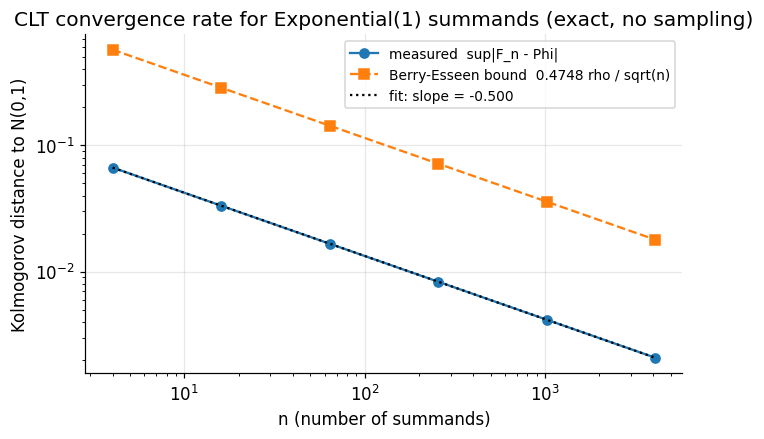

In [5]:
grid = np.linspace(-12.0, 12.0, 240_001)
Phi = norm.cdf(grid)
n_grid = np.array([4, 16, 64, 256, 1024, 4096])

ks = np.array([
    np.max(np.abs(gamma.cdf(n + grid * np.sqrt(n), a=n) - Phi)) for n in n_grid
])
rho_exp = 12 / np.e - 2          # E|X-1|^3 for X ~ Exponential(1)
be = 0.4748 * rho_exp / np.sqrt(n_grid)

slope, intercept = np.polyfit(np.log(n_grid), np.log(ks), 1)
print(f"rho = 12/e - 2 = {rho_exp:.6f}\n")
print(" n     sup|F_n - Phi|   halving ratio   Berry-Esseen bound   ratio")
for i, n in enumerate(n_grid):
    ratio = "     -    " if i == 0 else f"{ks[i-1] / ks[i]:9.4f}"
    print(f"{n:5d}   {ks[i]:.6f}     {ratio}          {be[i]:.4f}      {ks[i] / be[i]:.4f}")
print(f"\nmeasured log-log slope = {slope:.4f}   predicted = -0.5000")
assert abs(slope + 0.5) < 0.01
assert np.all(ks <= be)

fig, ax = plt.subplots()
ax.loglog(n_grid, ks, "o-", label="measured  sup|F_n - Phi|")
ax.loglog(n_grid, be, "s--", label="Berry-Esseen bound  0.4748 rho / sqrt(n)")
ax.loglog(n_grid, np.exp(intercept) * n_grid**slope, "k:",
          label=f"fit: slope = {slope:.3f}")
ax.set_xlabel("n (number of summands)")
ax.set_ylabel("Kolmogorov distance to N(0,1)")
ax.set_title("CLT convergence rate for Exponential(1) summands (exact, no sampling)")
ax.legend(fontsize=9)
plt.show()

The distance halves every time $n$ quadruples, and the fitted exponent is $-0.5004$ against
the predicted $-1/2$: the CLT error decays exactly at the Berry–Esseen rate, not faster. The
bound of Theorem 4.10 holds at every $n$ but is loose by a factor of about $8.6$, uniformly —
its constant is worst-case over all laws with the given $\rho/\sigma^3$, while Exponential$(1)$
is far from the worst case.

Next, the shape of the convergence rather than its speed: standardized sums of the same skewed
summand at $n = 1, 2, 5, 30$, with the $\mathcal{N}(0,1)$ density overlaid and the exact
Kolmogorov distance printed for each panel.

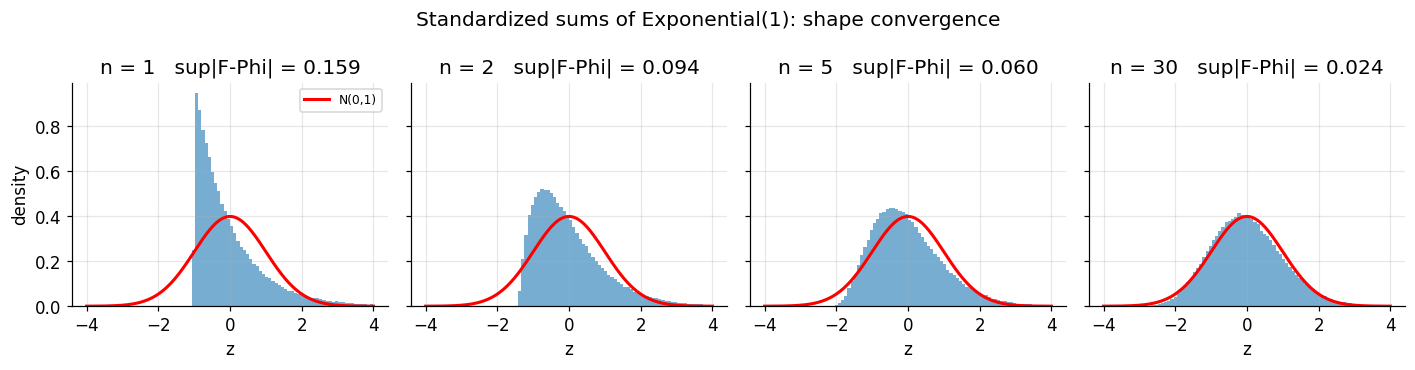

In [6]:
xs = np.linspace(-4.0, 4.0, 400)
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=True)
for ax, n in zip(axes, [1, 2, 5, 30]):
    z = (rng.exponential(1.0, size=(200_000, n)).sum(axis=1) - n) / np.sqrt(n)
    ax.hist(z, bins=90, range=(-4, 4), density=True, alpha=0.6, color="C0")
    ax.plot(xs, norm.pdf(xs), "r-", lw=2)
    d = np.max(np.abs(gamma.cdf(n + grid * np.sqrt(n), a=n) - Phi))
    ax.set_title(f"n = {n}   sup|F-Phi| = {d:.3f}")
    ax.set_xlabel("z")
axes[0].set_ylabel("density")
axes[0].plot([], [], "r-", lw=2, label="N(0,1)")
axes[0].legend(fontsize=8)
fig.suptitle("Standardized sums of Exponential(1): shape convergence")
fig.tight_layout()
plt.show()

At $n = 1$ the standardized summand is a shifted exponential, one-sided and sharply peaked. By
$n = 5$ the left tail has filled in and the peak has moved to the right place; by $n = 30$ the
residual asymmetry is invisible to the eye, though the exact Kolmogorov distance is still
$0.0243$, down only from $0.1587$ at $n = 1$ — the skewness of Proof 5.6 leaves at rate
$n^{-1/2}$, it does not disappear.

Now drop the hypotheses. The cell below removes finite variance in two ways: standard Cauchy,
where Definition 3.4 gives the exact law of $\bar{X}_n$ for every $n$, and Pareto$(\alpha=1.5)$,
which has a finite mean but infinite variance. If the CLT still applied, the Kolmogorov
distance would fall like $n^{-1/2}$ as in the previous cell.

In [7]:
d_cauchy = float(np.max(np.abs(cauchy.cdf(grid) - Phi)))
print(f"Cauchy: Xbar_n is exactly Cauchy(0,1) for every n, so sup|F - Phi| = "
      f"{d_cauchy:.5f} at every n (Proof 5.6)\n")


def ks_to_normal(sample):
    s = np.sort((sample - sample.mean()) / sample.std(ddof=1))
    m = s.size
    F = norm.cdf(s)
    return float(max(np.max(np.arange(1, m + 1) / m - F), np.max(F - np.arange(m) / m)))


reps, alpha_p = 20_000, 1.5
print(" n     Pareto(1.5)  sup|F_n - Phi|   Exponential(1) (finite variance)")
for n in [16, 64, 256, 1024, 4096]:
    tot_p = np.zeros(reps)
    tot_e = np.zeros(reps)
    for _ in range(n):                       # accumulate column by column: O(reps) memory
        tot_p += rng.uniform(size=reps) ** (-1 / alpha_p)
        tot_e += rng.exponential(1.0, size=reps)
    print(f"{n:5d}        {ks_to_normal(tot_p):.4f}                    {ks_to_normal(tot_e):.4f}")

Cauchy: Xbar_n is exactly Cauchy(0,1) for every n, so sup|F - Phi| = 0.12558 at every n (Proof 5.6)

 n     Pareto(1.5)  sup|F_n - Phi|   Exponential(1) (finite variance)
   16        0.3031                    0.0349
   64        0.3605                    0.0172
  256        0.3305                    0.0081


 1024        0.2483                    0.0058


 4096        0.3307                    0.0053


The finite-variance column falls steadily toward the sampling-noise floor $\approx 1/\sqrt{20000}$,
while the Pareto column wanders between $0.24$ and $0.37$ with no downward trend: with
$\sigma^2 = \infty$ the standardized sums converge to a $1.5$-stable law, not to a Gaussian, so
no amount of extra data rescues the approximation. The Cauchy case is worse still — the
distance is frozen at $0.1256$ for every $n$, because averaging does not change the law at all.
A $\sigma/\sqrt{n}$ error bar computed in either situation is not conservative, it is wrong.

Finally, the numerical-craft claim of Section 7.2: a hand-rolled Welford pass against the
library routine, and against the textbook-but-unstable formula $\overline{X^2} - \bar{X}^2$, on
data with a large offset.

In [8]:
def welford(x):
    """One-pass mean and unbiased variance (Welford, 1962)."""
    mean = 0.0
    m2 = 0.0
    for k, xk in enumerate(x, start=1):
        delta = xk - mean
        mean += delta / k
        m2 += delta * (xk - mean)
    return mean, m2 / (len(x) - 1)


data = 1e9 + rng.standard_normal(20_000)
w_mean, w_var = welford(data)
lib_mean, lib_var = float(np.mean(data)), float(np.var(data, ddof=1))
naive_var = float(np.mean(data**2) - np.mean(data) ** 2)

print(f"Welford   mean = {w_mean:.6f}   var = {w_var:.10f}")
print(f"NumPy     mean = {lib_mean:.6f}   var = {lib_var:.10f}")
print(f"naive E[X^2]-E[X]^2                var = {naive_var:.10f}")
print(f"\nWelford relative error = {abs(w_var - lib_var) / lib_var:.3e}")
print(f"naive   relative error = {abs(naive_var - lib_var) / lib_var:.3e}")
print(f"condition number |mean| / sd = {abs(lib_mean) / np.sqrt(lib_var):.3e}")
assert abs(w_mean - lib_mean) < 1e-6
assert abs(w_var - lib_var) / lib_var < 1e-6
assert abs(naive_var - lib_var) / lib_var > 1.0

Welford   mean = 999999999.991849   var = 0.9921307431
NumPy     mean = 999999999.991849   var = 0.9921307763
naive E[X^2]-E[X]^2                var = 384.0000000000

Welford relative error = 3.350e-08
naive   relative error = 3.860e+02
condition number |mean| / sd = 1.004e+09


The variance of this data is conditioned by the ratio $\vert\text{mean}\vert/\sigma \approx 10^{9}$.
The one-pass Welford recursion loses about one digit per power of that ratio and still returns
eight correct digits, agreeing with the two-pass `numpy.var` to a relative $3\times10^{-8}$.
The algebraically equivalent one-liner $\overline{X^2} - \bar{X}^2$ loses two digits per power
and returns $384$ in place of $0.992$ — a relative error of $386$, i.e. no correct digits at
all, because the two terms agree to $18$ digits before subtraction while double precision
carries about $16$. This is why the LLN's own estimate of $\sigma$ must be accumulated, never
differenced.

## 8. Applications

### 8.1 AI and machine learning

- **Stochastic gradient descent.** A minibatch gradient $\hat{g}_B = \frac{1}{B}\sum_{i \in B} \nabla \ell_i(\theta)$ is an unbiased estimator of the full gradient with covariance $\Sigma/B$. Theorem 4.3 says it points the right way on average; Theorem 4.7 says its noise is asymptotically Gaussian with scale $B^{-1/2}$, which underlies the SGD-as-SDE analysis $d\theta = -\nabla L\,dt + \sqrt{\eta/B}\,\Sigma^{1/2}dW$ and the linear scaling rule relating learning rate to batch size.
- **Empirical risk minimization.** Training loss is a sample mean of per-example losses, so the LLN is precisely the statement that empirical risk approximates true risk. Uniform versions over a hypothesis class — with VC dimension or Rademacher complexity replacing the fixed-function argument — are what make learning possible at all.
- **Evaluation and A/B testing.** Accuracy, click-through rate and win rate are averages of Bernoulli outcomes; the interval $\hat{p} \pm z\sqrt{\hat{p}(1-\hat{p})/n}$ is Corollary B of Proof 5.5, and Example 6.3 is the warning that it needs a continuity correction and enough successes.
- **Ensembling.** Averaging $M$ decorrelated models divides the variance component of the error by $M$; bagging and deep ensembles are the LLN applied to predictions instead of to data.
- **Initialization and normalization.** Pre-activations are sums of many weighted inputs, so Theorem 4.7 explains why they are approximately Gaussian at initialization, and motivates the He and Glorot variance scalings that hold $\operatorname{Var}$ constant across depth.

### 8.2 Physics and engineering

- **Thermal noise.** Johnson–Nyquist voltage noise is the aggregate of enormous numbers of independent carrier collisions; Theorem 4.7 is the reason its distribution is Gaussian with variance $4k_BTR\,\Delta f$ regardless of microscopic detail.
- **Brownian motion and diffusion.** A random walk with $n$ independent steps has displacement of order $\sigma\sqrt{n}$; passing to the continuum limit through the CLT yields the Gaussian heat kernel $p(x,t) = (4\pi Dt)^{-1/2}e^{-x^2/(4Dt)}$ and Einstein's relation $\langle x^2\rangle = 2Dt$.
- **Statistical mechanics.** Extensive quantities such as energy and magnetization are sums over $\sim 10^{23}$ weakly dependent degrees of freedom; relative fluctuations scale as $N^{-1/2}$, which is why thermodynamics looks deterministic.
- **Metrology and error propagation.** Repeated measurements shrink the standard error as $\sigma/\sqrt{n}$, and Theorem 4.13 is exactly the classical error-propagation formula $\sigma_g^2 \approx [g'(\theta)]^2\sigma_\theta^2$ made rigorous.
- **Where universality breaks.** Turbulent velocity increments, avalanche sizes at criticality and financial returns have heavy tails with $\alpha \lt 2$; there the scaling limits are Lévy stable laws, and $\sigma/\sqrt{n}$ error bars badly understate risk, as the Pareto column of Section 7 shows.

The cell below tests the SGD claim directly on a quadratic loss
$\ell_i(\theta) = \tfrac12(a_i^\top\theta - b_i)^2$: it measures the minibatch gradient
covariance trace at several batch sizes $B$ and compares it with the predicted
$\operatorname{tr}(\Sigma)/B$, where $\Sigma$ is the per-example gradient covariance.

In [9]:
d, N = 5, 4000
A = rng.standard_normal((N, d))
theta_true = rng.standard_normal(d)
b = A @ theta_true + 0.5 * rng.standard_normal(N)
theta = rng.standard_normal(d)                      # an arbitrary, non-optimal iterate

per_example = A * (A @ theta - b)[:, None]          # gradient of each l_i at theta
Sigma = np.cov(per_example.T, ddof=1)
trace_Sigma = float(np.trace(Sigma))
print(f"tr(Sigma) for a single example = {trace_Sigma:.4f}\n")
print("  B     measured tr Cov(g_B)   predicted tr(Sigma)/B    ratio")
for B in [1, 4, 16, 64, 256]:
    idx = rng.integers(0, N, size=(4000, B))
    grads = per_example[idx].mean(axis=1)
    measured = float(np.trace(np.cov(grads.T, ddof=1)))
    predicted = trace_Sigma / B
    print(f"{B:4d}        {measured:12.5f}        {predicted:12.5f}     {measured / predicted:.3f}")

tr(Sigma) for a single example = 61.6696

  B     measured tr Cov(g_B)   predicted tr(Sigma)/B    ratio
   1            63.37534            61.66961     1.028
   4            15.23788            15.41740     0.988
  16             3.73892             3.85435     0.970
  64             0.97898             0.96359     1.016
 256             0.23995             0.24090     0.996


The measured gradient-noise trace tracks $\operatorname{tr}(\Sigma)/B$ within a few percent
across two orders of magnitude in $B$: minibatch noise really does decay like $1/B$ in
variance, i.e. like $B^{-1/2}$ in magnitude. This is the exact content of the boxed identity of
Section 2 applied to gradients, and it is why doubling the batch size buys only a factor
$\sqrt{2}$ in gradient accuracy.

## 9. Key Takeaways

1. For independent summands with finite variance, $\operatorname{Var}(\bar{X}_n) = \sigma^2/n$ — the whole subject is the study of that one identity.
2. **Theorem 4.3 (weak LLN):** i.i.d. and $E\vert X_1\vert \lt \infty$ give $\bar{X}_n \xrightarrow{P} \mu$; with finite variance, Chebyshev makes the rate explicit at $n \ge \sigma^2/(\varepsilon^2\delta)$.
3. **Theorem 4.4 (strong LLN):** the same hypothesis $E\vert X_1\vert \lt \infty$ upgrades convergence to almost sure, and $E\vert X_1\vert = \infty$ destroys it completely — the threshold is sharp.
4. **Theorem 4.7 (CLT):** i.i.d. with $\sigma^2 \in (0,\infty)$ gives $\sqrt{n}(\bar{X}_n-\mu)/\sigma \xrightarrow{d} \mathcal{N}(0,1)$; the statement is about the magnified error, never about $\bar{X}_n$ itself.
5. **Theorem 4.10 (Berry–Esseen):** with $\rho = E\vert X_1-\mu\vert^3 \lt \infty$ the error is at most $0.4748\rho/(\sigma^3\sqrt{n})$, and Section 7 shows the exponent $-1/2$ is attained, so no universal threshold such as $n \ge 30$ can exist.
6. **Theorem 4.8 (Lindeberg–Feller):** identical distribution can be dropped for triangular arrays provided no single summand owns a non-vanishing share of the variance; Lyapunov's moment condition is the checkable sufficient version.
7. **Theorems 4.11–4.13 (Slutsky, continuous mapping, delta method):** plugging in a consistent $S_n$ for $\sigma$ is free asymptotically, and a smooth transform $g$ with $g'(\theta) \ne 0$ carries the limit through with variance $\sigma^2[g'(\theta)]^2$.
8. **Failure modes:** infinite variance replaces the Gaussian limit by an $\alpha$-stable law, and a non-existent mean (Cauchy) leaves $\bar{X}_n$ with exactly the law of $X_1$ for every $n$.

## 10. References

| Source | Chapters / sections | Coverage |
|---|---|---|
| Blitzstein & Hwang, *Introduction to Probability*, 2nd ed. | Ch. 10 | Inequalities, LLN and CLT with intuition-first exposition. |
| Wasserman, *All of Statistics* | Ch. 5 (Thms 5.5–5.13) | Convergence modes, Slutsky, delta method, compact proofs. |
| Casella & Berger, *Statistical Inference*, 2nd ed. | §5.5, §10.1 | Convergence concepts and asymptotic evaluation of estimators. |
| Billingsley, *Probability and Measure*, 3rd ed. | §6, §26 (Thm 26.3), §27 (Thm 27.2) | Borel–Cantelli, Lévy continuity, Lindeberg CLT. |
| Durrett, *Probability: Theory and Examples*, 5th ed. | §2.4 (Thm 2.4.1), §3.4 | Kolmogorov's SLLN, triangular arrays, stable laws. |
| Feller, *An Introduction to Probability Theory*, Vol. 2, 2nd ed. | §XVI.5, Ch. XVII | Berry–Esseen, Edgeworth expansions, domains of attraction. |
| Boucheron, Lugosi & Massart, *Concentration Inequalities* | Ch. 2–6 | Hoeffding, Bernstein, bounded-difference finite-sample bounds. |
| Bishop, *Pattern Recognition and Machine Learning* | §2.3 | The Gaussian as the limit of sums, in an ML setting. |
| Murphy, *Probabilistic Machine Learning: An Introduction* | Ch. 2, Ch. 8 | Monte Carlo approximation and SGD noise. |

**Reading path.** Blitzstein & Hwang Ch. 10 for intuition and worked examples; Wasserman Ch. 5 for the convergence-mode taxonomy and the delta method; Billingsley §26–§27 for the characteristic-function proof at full rigour, including the Lévy continuity theorem cited as Theorem 4.6; then Boucheron, Lugosi & Massart for the finite-sample concentration tools that modern machine-learning theory actually uses.